In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv("../dataset/toyona_gold_cleaned.csv")
df.head()

,возраст,пол,семейное положение,количество иждивенцев,профессия,статус клиента,зарплата,сумма кредита,ежемесячное погашение по графику,активные кредиты,первоначальный взнос,наличие карты,филиал,название продукта,is_bad_client
0,36.0,male,женат,3.0,oqituvchi,активный,3800000.0,3746724,312227,1,0,нет,turkiston,кулон,0
1,34.0,female,замужем,3.0,ishchi,активный,4000000.0,4925970,410497,1,0,да,turkiston,кулон,0
2,32.0,female,замужем,0.0,ishchi,активный,3000003.0,3000364,250030,1,0,нет,navoiy,кулон,0
3,33.0,female,замужем,3.0,tarbiyachi,активный,3300000.0,2597329,216444,1,0,да,navoiy,бугдой,0
4,72.0,female,замужем,4.0,nafaqa,активный,2700000.0,7550547,629212,1,0,да,navoiy,комплект,0


In [3]:
df['is_bad_client'].value_counts()

0    580
1     80
Name: is_bad_client, dtype: int64

In [4]:
npl_ratio = df["is_bad_client"].mean() * 100
print(f"NPL: {npl_ratio:.2f}%")

NPL: 12.12%


In [5]:
import pickle
with open("../model/toyona_gold_rf_model.pkl", "rb") as f:
    model = pickle.load(f)

In [6]:
X = df.drop(columns=["is_bad_client"])
y = df["is_bad_client"]

In [7]:
X.head()

,возраст,пол,семейное положение,количество иждивенцев,профессия,статус клиента,зарплата,сумма кредита,ежемесячное погашение по графику,активные кредиты,первоначальный взнос,наличие карты,филиал,название продукта
0,36.0,male,женат,3.0,oqituvchi,активный,3800000.0,3746724,312227,1,0,нет,turkiston,кулон
1,34.0,female,замужем,3.0,ishchi,активный,4000000.0,4925970,410497,1,0,да,turkiston,кулон
2,32.0,female,замужем,0.0,ishchi,активный,3000003.0,3000364,250030,1,0,нет,navoiy,кулон
3,33.0,female,замужем,3.0,tarbiyachi,активный,3300000.0,2597329,216444,1,0,да,navoiy,бугдой
4,72.0,female,замужем,4.0,nafaqa,активный,2700000.0,7550547,629212,1,0,да,navoiy,комплект


In [8]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_bad_client, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [11]:
len(X_train), len(X_test), len(y_train), len(y_test)

(462, 198, 462, 198)

In [12]:
y_pred = model.predict(X_test)  
y_proba = model.predict_proba(X_test)[:, 1]

In [13]:
y_test.value_counts()

0    174
1     24
Name: is_bad_client, dtype: int64

In [14]:
npl_ratio = y_test.mean() * 100
print(f"NPL: {npl_ratio:.2f}%")

NPL: 12.12%


In [15]:
print("Classification Report (по 0/1):")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report (по 0/1):
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       174
           1       0.69      0.75      0.72        24

    accuracy                           0.93       198
   macro avg       0.83      0.85      0.84       198
weighted avg       0.93      0.93      0.93       198

Confusion Matrix:
[[166   8]
 [  6  18]]
ROC-AUC: 0.9468390804597702


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix


thresholds = np.linspace(0, 1, 101)
f1_scores, precisions, recalls, npls, accuracies = [], [], [], [], []
tps, tns, fps, fns = [], [], [], []

thrs = []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    
    
    tp, fp, fn, tn = confusion_matrix(y_test, y_pred_thr).ravel()

    tps.append(tp)
    tns.append(tn)
    fps.append(fp)
    fns.append(fn)

    npl = fn / (fn + tp) if (tp + fn) > 0 else 0
    npls.append(round(npl*100, 2))

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    precisions.append(round(prec *100,2))

    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    recalls.append(round(rec *100, 2))

    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    f1_scores.append(round(f1 *100 ,2))

    acc = (tp + tn) / (tp + tn + fp + fn)
    accuracies.append(round(acc *100 ,2))

    thrs.append(round(thr * 100, 2))

results = pd.DataFrame({
    "threshold": thrs,
    "precision": precisions,
    "recall": recalls,
    "f1": f1_scores,
    "accuracy": accuracies,
    "npl": npls,
    "tp": tps,
    "tn": tns,
    "fp": fps,
    "fn": fns
})

results.to_csv("metrics_thresholds.csv", index=False)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Лучший порог: {best_threshold:.2f}")
print(f"F1-score: {f1_scores[best_idx]:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall: {recalls[best_idx]:.4f}")
print(f"NPL: {npls[best_idx]:.4f}")
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Лучший порог: 0.66
F1-score: 96.9200
Precision: 99.4300
Recall: 94.5400
NPL: 5.4600
ROC-AUC: 0.9468390804597702


In [66]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, confusion_matrix

def find_best_threshold_balanced(model, X_valid, y_valid, beta=1.0, grid_size=101, f1_tol=0.01,
                                 min_precision=None, min_recall=None):
    
    y_proba = model.predict_proba(X_valid)[:, 1]
    thresholds = np.linspace(0.0, 1.0, grid_size)

    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
        
    
        prec = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
        fbet = fbeta_score(y_valid, y_pred, beta=beta, zero_division=0) * 100
        npl = (fn / (tp + fn)) * 100 if (tp + fn) > 0 else np.nan
        acc = (tp + tn) / (tp + tn + fp + fn) * 100

        rows.append((int(round(t * 100)), round(prec, 2), round(rec, 2), round(f1, 2), round(fbet, 2), round(acc, 2), round(abs(prec - rec), 2), npl))

    metrics_df = pd.DataFrame(
        rows,
        columns=["threshold", "precision", "recall", "f1", "f_beta", "accuracy", "prec_recall_gap", "npl"]
    )

    cand = metrics_df.copy()

    if min_precision is not None:
        cand = cand[cand["precision"] >= min_precision]
    if min_recall is not None:
        cand = cand[cand["recall"] >= min_recall]
    

    if cand.empty:
        cand = metrics_df

    score_col = "f1" if beta == 1.0 else "f_beta"
    max_score = cand[score_col].max()
    
   
    near_opt = cand[cand[score_col] >= max_score * (1 - f1_tol)]
   
 
    best_row = near_opt.sort_values(
        ["prec_recall_gap", score_col, "threshold"],
        ascending=[True, False, True]
    ).iloc[0]
    
    best_threshold = float(best_row["threshold"])
    

    return best_threshold, metrics_df, best_row

In [67]:
best_thr, metrics_table, best_metrics = find_best_threshold_balanced(
    model, X_test, y_test,
    beta=1.0,
    grid_size=101,
    f1_tol=0.01
)

print(f"Лучший порог: {best_thr:.3f}")
print("Метрики на лучшем пороге:")
print(best_metrics)

Лучший порог: 66.000
Метрики на лучшем пороге:
threshold          66.00
precision          91.67
recall             68.75
f1                 78.57
f_beta             78.57
accuracy           95.45
prec_recall_gap    22.92
npl                31.25
Name: 66, dtype: float64


In [68]:
best_thr

66.0

In [69]:
best_thr = best_thr / 100 

In [70]:
metrics_df_copy = metrics_table.copy()

In [71]:
df_metrics = metrics_df_copy[['threshold', 'precision', 'recall', 'f1', 'accuracy', 'npl']]

In [72]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_opt = (y_proba >= best_thr).astype(int)

print("\nClassification report @ optimal threshold:", best_thr *100)
print(classification_report(y_test, y_pred_opt, digits=2))
print("Confusion matrix @ optimal threshold:", best_thr *100)
print(confusion_matrix(y_test, y_pred_opt))

print("\nTop 10 порогов по F1 + баланс precision/recall + NPL:")
print(
    df_metrics.sort_values(["f1"], ascending=[False,])
                 .head(10)
                 .round(3)
)



Classification report @ optimal threshold: 66.0
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       116
           1       0.92      0.69      0.79        16

    accuracy                           0.95       132
   macro avg       0.94      0.84      0.88       132
weighted avg       0.95      0.95      0.95       132

Confusion matrix @ optimal threshold: 66.0
[[115   1]
 [  5  11]]

Top 10 порогов по F1 + баланс precision/recall + NPL:
    threshold  precision  recall     f1  accuracy    npl
66         66      91.67   68.75  78.57     95.45  31.25
65         65      84.62   68.75  75.86     94.70  31.25
67         67      90.91   62.50  74.07     94.70  37.50
68         68      90.91   62.50  74.07     94.70  37.50
62         62      78.57   68.75  73.33     93.94  31.25
63         63      78.57   68.75  73.33     93.94  31.25
64         64      78.57   68.75  73.33     93.94  31.25
61         61      78.57   68.75  73.33     93.

In [73]:
df_metrics.to_csv("toyona_gold_metrics_table.csv", index=False)

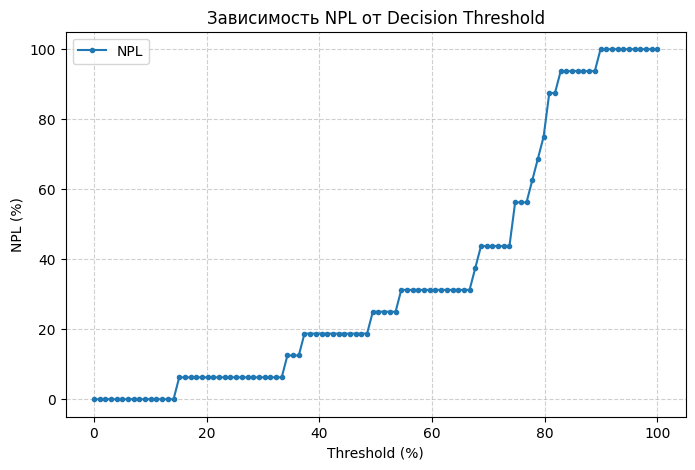

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def npl_at_thresholds(y_true, y_proba, thresholds):
    npl_scores = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        #NPL = FN / (TP + FN)
        if (tp + fn) > 0:
            npl = fn / (tp + fn)
        else:
            npl = np.nan
        npl_scores.append(npl)
    return npl_scores


thresholds = np.linspace(0, 1, 100)
npl_values = npl_at_thresholds(y_test, y_proba, thresholds)


plt.figure(figsize=(8,5))
plt.plot(thresholds * 100, np.array(npl_values) * 100, marker="o", markersize=3, label="NPL")
plt.xlabel("Threshold (%)")
plt.ylabel("NPL (%)")
plt.title("Зависимость NPL от Decision Threshold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

